**Initial approach to understanding the chemical space of the APKR reactions in the database**\
*date created: 08.13.2026*\
*last modification: 08.13.2026*\
database in use: 'apkr_reactions.db\
**general plan of action:**
1. Check to make sure all excel sheets within folder '../0.database_excels/' have been added to the combined data (all_data)
2. Take all substrate SMILES strings and use RDKit to convert to a grid image of the structures (save in '../2.png_files/')
3. Generate fingerprint parameters from SMILES strings (Morgan fingerprints)\
        a. The Morgan fingerprints will be added to a table in the database 'apkr_reactions.db'
4. Try multiple clustering techniques to cluster substrates

In [10]:
from pathlib import Path
from database_commands import update_database, troubleshooting, clean_slate
import sqlite3
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from datetime import datetime

database_name = 'apkr_reactions.db'

now = datetime.now()
timestamp_string = now.strftime("%m.%d.%Y")
print(timestamp_string)

08.19.2026


In [11]:
# RUN this cell if tables have been updated

# data_path = Path("../0.database_excels/")       # directory where excel sheets are located
# sheet_list = [f.name for f in data_path.iterdir() if f.is_file()]
# sheet_list.remove('template.xlsx')

# clean_slate()
# troubleshooting(type='reload data', sheet_list=sheet_list)

In [12]:
# Checks if all the current excel sheets have been added to the 'all_data' table 
data_path = Path("../0.database_excels/")       # directory where excel sheets are located
sheet_list = [f.name for f in data_path.iterdir() if f.is_file()]
sheet_list.remove('template.xlsx')

conn = sqlite3.connect(database_name)
cur = conn.cursor()

cur.execute("SELECT sheet_name FROM added_sheets")
already_added = {row[0] for row in cur.fetchall()}
conn.close()

yet_to_upload = []
for entry in sheet_list:
    if entry not in already_added:
        yet_to_upload.append(entry)

if yet_to_upload:
    print("Not yet in database:", sorted(yet_to_upload))
    update_database(sheet_list=yet_to_upload)
else:
    print("Good to go! All sheets are in database.")

conn = sqlite3.connect(database_name)
cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM all_data")
reaction_num = cur.fetchone()[0]
conn.close()
print(f'{reaction_num} in database.')


Not yet in database: ['Jeong_ChemCommun_2004_08.19.2026.xlsx', 'Jeong_JACS_2000_08.19.2026.xlsx']
Successfully added 2 to apkr_reactions.db
Skipping 'Burrows_JACS_2017_08.07.2026.xlsx' -- already in 'all_data'
Skipping 'Cristobal-Lecina_Organometallics_2015_08.16.2026.xlsx' -- already in 'all_data'
Skipping 'Fan_Adv-Synth-Catal_2005_08.13.2026.xlsx' -- already in 'all_data'
Skipping 'Fuji_Tetrahedron_Lett_2004_08.16.2026.xlsx' -- already in 'all_data'
Skipping 'Furusawa_Tetrahedron_2015_08.16.2026.xlsx' -- already in 'all_data'
Skipping 'Haghighi_JACS_2025_08.19.2026.xlsx' -- already in 'all_data'
Skipping 'Hayashi_ChemAsianJ_2023_08.19.2026.xlsx' -- already in 'all_data'
Skipping 'Jeong_ChemCommun_2004_08.16.2026.xlsx' -- already in 'all_data'
Skipping 'Kim_AdvSynthCatal_2008_08.13.2026.xlsx' -- already in 'all_data'
Skipping 'Kim_JOC_2008_08.07.2026.xlsx' -- already in 'all_data'
Skipping 'Kwong_Adv-Synth-Catal_2005_08.13.2026.xlsx' -- already in 'all_data'
Skipping 'Qi_ACS-Catal_202

In [13]:
# Extract all SMILES strings from the database
conn = sqlite3.connect(database_name)
conn.row_factory = lambda cursor, row: row[0]
cur = conn.cursor()

cur.execute('SELECT "Substrate SMILES" FROM all_data')
sub_smiles_list = cur.fetchall()
conn.close()

# canonicalized all SMILES using RDKit
canon_sub_smiles = []
for s in sub_smiles_list:
    canon_smiles = Chem.CanonSmiles(s)
    canon_sub_smiles.append(canon_smiles)
# Removes duplicate SMILES
unique_canon_sub_smiles = []
for s in canon_sub_smiles: 
    if s not in unique_canon_sub_smiles:
        unique_canon_sub_smiles.append(s)

print(f'Original # of SMILES: {len(sub_smiles_list)}')
print(f'After canonicalization and duplicate removal: {len(unique_canon_sub_smiles)}')



Original # of SMILES: 583
After canonicalization and duplicate removal: 136


In [14]:
# Generates Morgan fingerprints for all unique substrate SMILES 
# Save Morgan fingerprints to 'morgan_fingerprints'

from rdkit.Chem import rdFingerprintGenerator

fp_data = []
conv_smiles = []
failed = []

# generator = AllChem.GetMorganFingerprintAsBitVect(radius=2, nBits=1024)

smiles = unique_canon_sub_smiles
pairs = [(s, Chem.MolFromSmiles(s)) for s in smiles]
pairs = [(s, m) for s, m in pairs if m is not None]
smiles_ok = [s for s, _ in pairs]
mols      = [m for _, m in pairs]

gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
X = np.array([gen.GetFingerprintAsNumPy(m) for m in mols], dtype=np.float64)

print(X.shape)


(136, 1024)


#### Chemical Space Analysis
*Using procedure from Mithun's SI*

In [15]:
# Run PCA to retain 80 components from the Morgan Fingerprints
from sklearn.decomposition import PCA 

# Makes sure fp is readable by PCA
pca = PCA(n_components=80, random_state=42)
X_pca = pca.fit_transform(X)

print(X_pca.shape, pca.explained_variance_ratio_.sum())

# There should be (n_of_smiles, 80)

(136, 80) 0.9874947475068744


In [19]:
# t-SNE with the following hyperparameters:
# perplexity = 20, maximum iterations = 3000
# early exaggeration factor = 15, learning rate = 150
from sklearn.manifold import TSNE
from sklearn.cluster import HDBSCAN

# Initializes t-SNE
tsne = TSNE(n_components=2, 
              perplexity=20, 
              max_iter=3000, 
              learning_rate=150, 
              early_exaggeration=15,
              init="pca",
              random_state=42)

X_tsne = tsne.fit_transform(X_pca)      # (n_molecules, 2)

X_tsne_centered = X_tsne - X_tsne.mean(axis=0)

# HDBSCAN on the 2D coordinates
clusterer = HDBSCAN(min_cluster_size=5, min_samples=5)
labels = clusterer.fit_predict(X_tsne_centered)

n_clusters = len(set(labels) - {-1})
n_noise = int((labels == 1).sum())
print(f"{n_clusters} cluster, {n_noise} noise points of {len(labels)}")

# Create a new DataFrame for the t-SNE result
tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df["Smiles"] = smiles

tsne_df.to_csv(f"tsne_{timestamp_string}.csv", index=False)

print(tsne_df.head())


8 cluster, 16 noise points of 136
      TSNE1     TSNE2                                   Smiles
0  5.571414 -8.271494         CC(=O)OC=C=C(C)CCCC#C[Si](C)(C)C
1  5.548554 -8.965165  CC(=C=COC(=O)C(C)(C)C)CCCC#C[Si](C)(C)C
2  4.841505 -8.799001   CCCCCCCC(=O)OC=C=C(C)CCCC#C[Si](C)(C)C
3  6.583576 -8.626671  CC(=C=COC(=O)c1ccccc1)CCCC#C[Si](C)(C)C
4  6.291579 -7.266180            CC(=O)OC=C=C(C)CCCC#Cc1ccccc1


c:\Users\hbos2\miniconda3\envs\trex\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


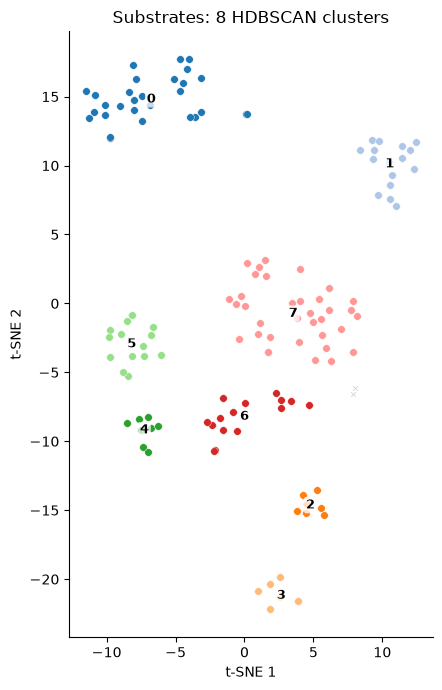

In [17]:
# Ploting t-SNE from PCA using HDBSCAN clustering
import matplotlib.pyplot as plt

labels_unique =sorted(set(labels) - {-1})
cmap = plt.get_cmap("tab20")

fig, ax = plt.subplots(figsize=(7,7))

# plots  noise first
noise = labels == -1
ax.scatter(X_tsne_centered[noise,0], X_tsne_centered[noise, 1],
           s=12, c='lightgrey', marker="x", linewidths=0.6, 
           label=f"Noise ({noise.sum()})", zorder=1)

for i, lab in enumerate(labels_unique):
    m = labels == lab
    ax.scatter(X_tsne_centered[m,0], X_tsne_centered[m,1], 
               s=30, color=cmap(i % 20), edgecolors="white", linewidth=0.3,
               label=f"{lab} (n={m.sum()})", zorder=2)
    # cluster number at the centroid
    cx, cy = X_tsne_centered[m,0].mean(), X_tsne_centered[m,1].mean()
    ax.text(cx, cy, str(lab), fontsize=9, fontweight='bold',
            ha='center', va='center', zorder=3,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75))

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f"Substrates: {len(labels_unique)} HDBSCAN clusters")
ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(f"../2.png_files/tsne_hdbscan_{timestamp_string}.png", dpi=300, bbox_inches="tight")
plt.show()

# Gets list of smiles in each cluster 
cluster_df = pd.DataFrame({
    "smiles": smiles_ok,
    "cluster": labels, 
    "tsne_1": X_tsne_centered[:,0],
    "tnse_2": X_tsne_centered[:,1],
})

# save to excel sheet
cluster_df.to_csv(f"cluster_{timestamp_string}.csv", index=False)



In [18]:
# Use RDKit to show which smiles are in which cluster
import os
from rdkit import Chem
from rdkit.Chem import Draw

outdir = "../2.png_files"
os.makedirs(outdir, exist_ok=True)

for lab in labels_unique:                       # actual labels, not range()
    sub = cluster_df[cluster_df["cluster"] == lab]   # == not is
    smiles_list = sub["smiles"].tolist()

    # print(f"\nCluster {lab} (n={len(smiles_list)})")
    # for s in smiles_list:
    #     print("  ", s)

    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    mols = [m for m in mols if m is not None]
    if not mols:
        continue

    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(200, 200),
        legends=[f"{lab}-{j}" for j in range(len(mols))],
        maxMols=len(mols),          # default is 50 — silently truncates!
        useSVG=False,
        returnPNG=False,            # forces a PIL Image back
    )
    img.save(os.path.join(outdir, f"cluster_{lab}_{timestamp_string}.png"))   # needs .png